# Trabalho de LPA - G13

---
### 1 - Análise Exploratória de dados

---
A partir da base de dados precos_carros_brasil.csv, execute as seguintes tarefas:
1. Carregue a base
2. Verifique se há valores faltantes nos dados. Caso haja, escolha uma tratativa para resolver o problema de valores faltantes
3. Verifique se há dados duplicados nos dados
4. Crie duas categorias, para separar colunas numéricas e categóricas. Imprima o resumo de informações das variáveis numéricas e categóricas (estatística descritiva dos dados)
5. Imprima a contagem de valores por modelo (model) e marca do carro (brand)
6. Dê um breve explicação (máximo de quatro linhas) sobre os principais resultados encontrados na Análise Exploratória dos dados

---

In [1]:
# Carregar bibliotecas
import pandas as pd
# Biblioteca Seaborn - Criação de gráficos
import seaborn as sns
# Biblioteca Matplotlib - Criação de gráficos
import matplotlib.pyplot as plt
# Biblioteca matemática
import numpy as np

# OPCIONAL - Biblioteca para ignorar mensagens de warning (aviso) ao rodar uma célula de código
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Bibliotecas de machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Métricas de avaliação dos modelos
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

---
1. Carregue a base de dados precos_carros_brasil.csv

In [3]:
# Ler o arquivo .csv
dados = pd.read_csv("precos_carros_brasil.csv")
lst_colunas = dados.columns
print("Lista das colunas ",lst_colunas)

Lista das colunas  Index(['year_of_reference', 'month_of_reference', 'fipe_code',
       'authentication', 'brand', 'model', 'fuel', 'gear', 'engine_size',
       'year_model', 'avg_price_brl'],
      dtype='str')


---
2. Verifique se há valores faltantes nos dados. Caso haja, escolha uma tratativa para
resolver o problema de valores faltantes 

In [4]:
# Examinar a base de dados
dados.shape

(267542, 11)

267542 Linhas e 11 Colunas

In [5]:
# Verifica se existe valores faltantes
dados.isna().any()

year_of_reference     True
month_of_reference    True
fipe_code             True
authentication        True
brand                 True
model                 True
fuel                  True
gear                  True
engine_size           True
year_model            True
avg_price_brl         True
dtype: bool

In [6]:
# Remove linhas com valores em branco
dados.dropna(axis=0, how='all', inplace=True)

In [7]:
# Verifica se ainda existem linhas com valores em branco
dados.isna().any()

year_of_reference     False
month_of_reference    False
fipe_code             False
authentication        False
brand                 False
model                 False
fuel                  False
gear                  False
engine_size           False
year_model            False
avg_price_brl         False
dtype: bool

In [8]:
#Linhas que sobraram:
dados.shape

(202297, 11)

202297 Linhas e 11 Colunas

---
3. Verifique se há dados duplicados nos dados

In [9]:
# Verifica se existem duplicados
dados.duplicated().sum() 

np.int64(2)

In [10]:
# Remover duplicados
dados.drop_duplicates(inplace=True)
dados.shape

(202295, 11)

202295 Linhas e 11 Colunas

---
4. Crie duas categorias, para separar colunas numéricas e categóricas. Imprima o resumo

In [11]:
# Criando categorias para separar colunas numéricas e categóricas: facilita a AED
numericas_cols = [col for col in dados.columns if dados[col].dtype != 'str']
categoricas_cols = [col for col in dados.columns if dados[col].dtype == 'str']
print("Lista de colunas numéricas ", numericas_cols)
print("\nLista de colunas categóricas ", categoricas_cols)

Lista de colunas numéricas  ['year_of_reference', 'year_model', 'avg_price_brl']

Lista de colunas categóricas  ['month_of_reference', 'fipe_code', 'authentication', 'brand', 'model', 'fuel', 'gear', 'engine_size']


---
5. Imprima a contagem de valores por modelo (model) e marca do carro (brand)

In [12]:
# Quantidade de valores por modelo
dados['model'].value_counts()

model
Palio Week. Adv/Adv TRYON 1.8 mpi Flex    425
Focus 1.6 S/SE/SE Plus Flex 8V/16V 5p     425
Focus 2.0 16V/SE/SE Plus Flex 5p Aut.     400
Saveiro 1.6 Mi/ 1.6 Mi Total Flex 8V      400
Corvette 5.7/ 6.0, 6.2 Targa/Stingray     375
                                         ... 
STEPWAY Zen Flex 1.0 12V Mec.               2
Saveiro Robust 1.6 Total Flex 16V CD        2
Saveiro Robust 1.6 Total Flex 16V           2
Gol Last Edition 1.0 Flex 12V 5p            2
Polo Track 1.0 Flex 12V 5p                  2
Name: count, Length: 2112, dtype: int64

In [13]:
# Quantidade de diferentes modelos
dados['model'].nunique()

2112

In [14]:
# Quantidade de valores por marca
dados['brand'].value_counts()

brand
Fiat               44962
VW - VolksWagen    44312
GM - Chevrolet     38590
Ford               33150
Renault            29191
Nissan             12090
Name: count, dtype: int64

In [15]:
# Quantidade de diferentes marcas
dados['brand'].nunique()

6

---
6. Dê um breve explicação (máximo de quatro linhas) sobre os principais resultados
encontrados na Análise Exploratória dos dados

A Base original continha 267542 linhas, sendo que dessas, 65245 eram linhas em branco e duas linhas duplicadas, restando 202295 linhas (uma redução de 24% no tamanho da base original). Existem 2112 modelos diferentes, divididos em 6 diferentes marcas.
Os Modelos que mais aparecem são o 'Palio Week. Adv/Adv TRYON 1.8 mpi Flex' e o 'Focus 1.6 S/SE/SE Plus Flex 8V/16V 5p', cada um 425 ocorrências. O Fabricante (marca) que mais ocorre é 'Fiat' com 44962 registros.


---
### 2 - Visualização dos dados

---
A partir da base de dados precos_carros_brasil.csv, execute as seguintes tarefas:
1. Gere um gráfico da distribuição da quantidade de carros por marca
2. Gere um gráfico da distribuição da quantidade de carros por tipo de engrenagem do carro
3. Gere um gráfico da evolução da média de preço dos carros ao longo dos meses de 2022 (variável de tempo no eixo X)
4. Gere um gráfico da distribuição da média de preço dos carros por marca e tipo de engrenagem
5. Dê uma breve explicação (máximo de quatro linhas) sobre os resultados gerados no
item 4
6. Gere um gráfico da distribuição da média de preço dos carros por marca e tipo de
combustível
7. Dê uma breve explicação (máximo de quatro linhas) sobre os resultados gerados no
item 6

---
1. Gere um gráfico da distribuição da quantidade de carros por marca

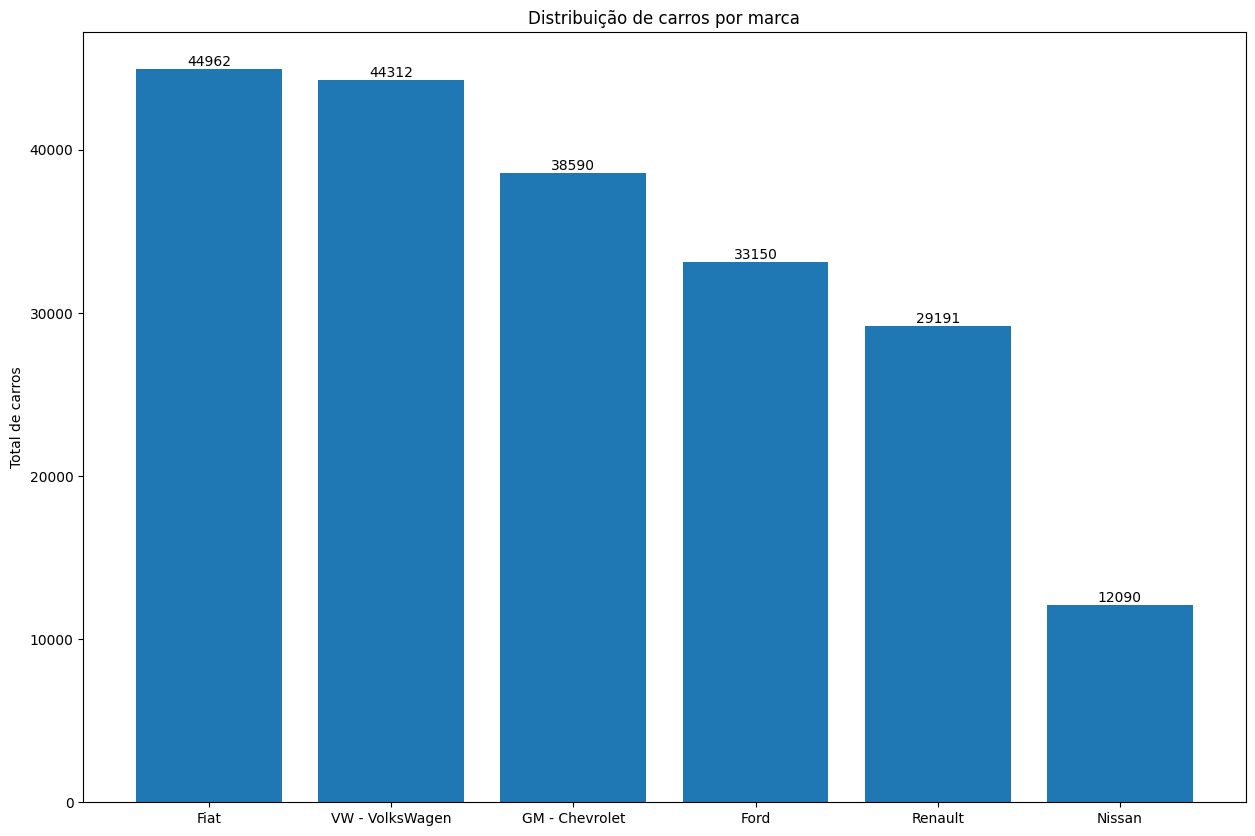

In [16]:
# Gráfico da distribuição de quantidade de carros por marca

carros_por_marca = dados['brand'].value_counts()
plt.figure(figsize=(15,10))
grafico_1 = plt.bar(carros_por_marca.index, carros_por_marca.values)
plt.title('Distribuição de carros por marca')
plt.ylabel('Total de carros')
plt.bar_label(grafico_1, size=10)
plt.show()


---
2. Gere um gráfico da distribuição da quantidade de carros por tipo de engrenagem do carro

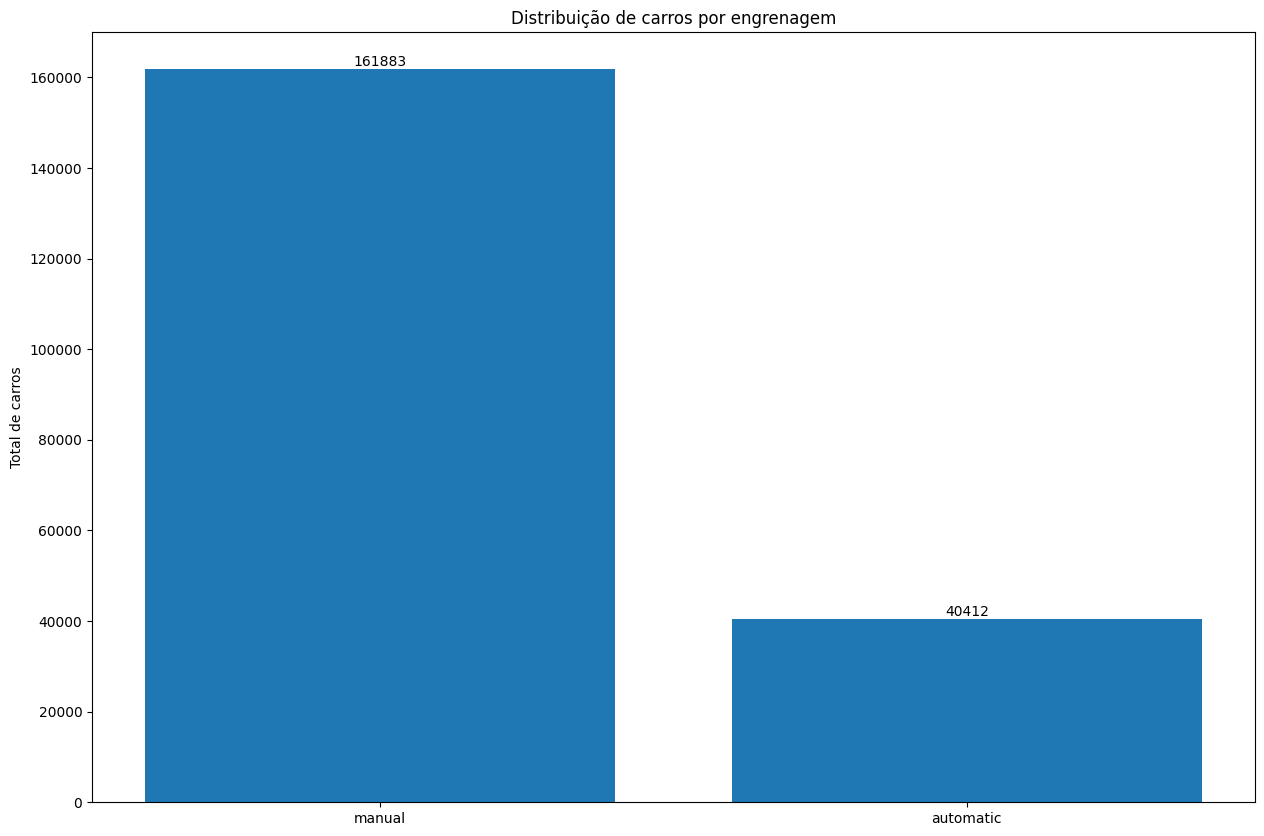

In [17]:
# Gráfico da distribuição de carros por tipo de engrenagem

carros_por_engrenagem = dados['gear'].value_counts()
plt.figure(figsize=(15,10))
grafico_2 = plt.bar(carros_por_engrenagem.index, carros_por_engrenagem.values)
plt.title('Distribuição de carros por engrenagem')
plt.ylabel('Total de carros')
plt.bar_label(grafico_2, size=10)
plt.show()

---
3. Gere um gráfico da evolução da média de preço dos carros ao longo dos meses de 2022 (variável de tempo no eixo X)

In [18]:
# Calcula a média por ano
media_valor_mensal_ano = dados.groupby(['year_of_reference', 'month_of_reference'])['avg_price_brl'].mean().round(0) # round para arrendodar
media_valor_mensal_ano = media_valor_mensal_ano.reset_index(name='valor_medio')

In [19]:
# Filtra apenas 2022
media_2022 = media_valor_mensal_ano[media_valor_mensal_ano['year_of_reference'] == 2022]
media_2022


,year_of_reference,month_of_reference,valor_medio
12,2022.0,April,57150.0
13,2022.0,August,57924.0
14,2022.0,December,57997.0
15,2022.0,February,55825.0
16,2022.0,January,54840.0
17,2022.0,July,57894.0
18,2022.0,June,58066.0
19,2022.0,March,56849.0
20,2022.0,May,57800.0
21,2022.0,November,58216.0


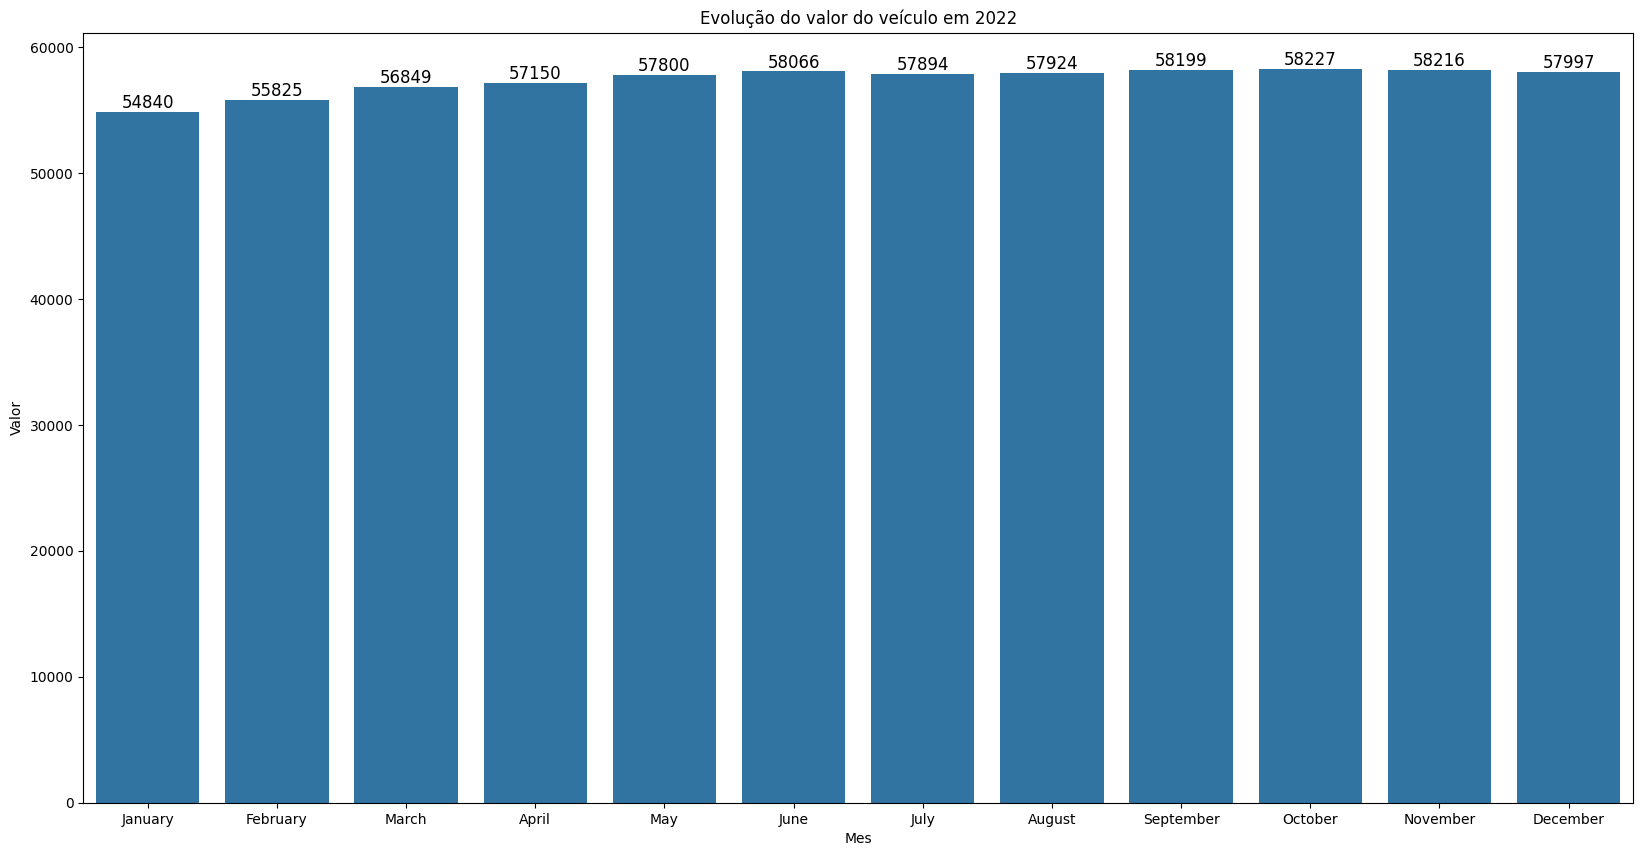

In [20]:
# Visualizando o valor médio do ano de 2022
# Cria lista de meses ordenado
months = ['January','February','March','April','May','June','July','August','September','October','November','December']

plt.figure(figsize=(20,10))
plt.title('Evolução do valor do veículo em 2022')
plt.ylabel('Valor')
plt.xlabel('Mes')
ax = sns.barplot(x='month_of_reference', y='valor_medio', order=months, data=media_2022)
for container in ax.containers:
    ax.bar_label(container, size=12)
plt.show()

---
4. Gere um gráfico da distribuição da média de preço dos carros por marca e tipo de engrenagem

In [21]:
# Calcula a média por marca e tipo de engrenagem
media_valor_marca_gear = dados.groupby(['brand', 'gear'])['avg_price_brl'].mean().round(0) # round para arrendodar
media_valor_marca_gear = media_valor_marca_gear.reset_index(name='valor_medio')

In [22]:
media_valor_marca_gear

,brand,gear,valor_medio
0,Fiat,automatic,97397.0
1,Fiat,manual,39694.0
2,Ford,automatic,84769.0
3,Ford,manual,51784.0
4,GM - Chevrolet,automatic,88157.0
5,GM - Chevrolet,manual,52119.0
6,Nissan,automatic,94231.0
7,Nissan,manual,52681.0
8,Renault,automatic,44028.0
9,Renault,manual,47649.0


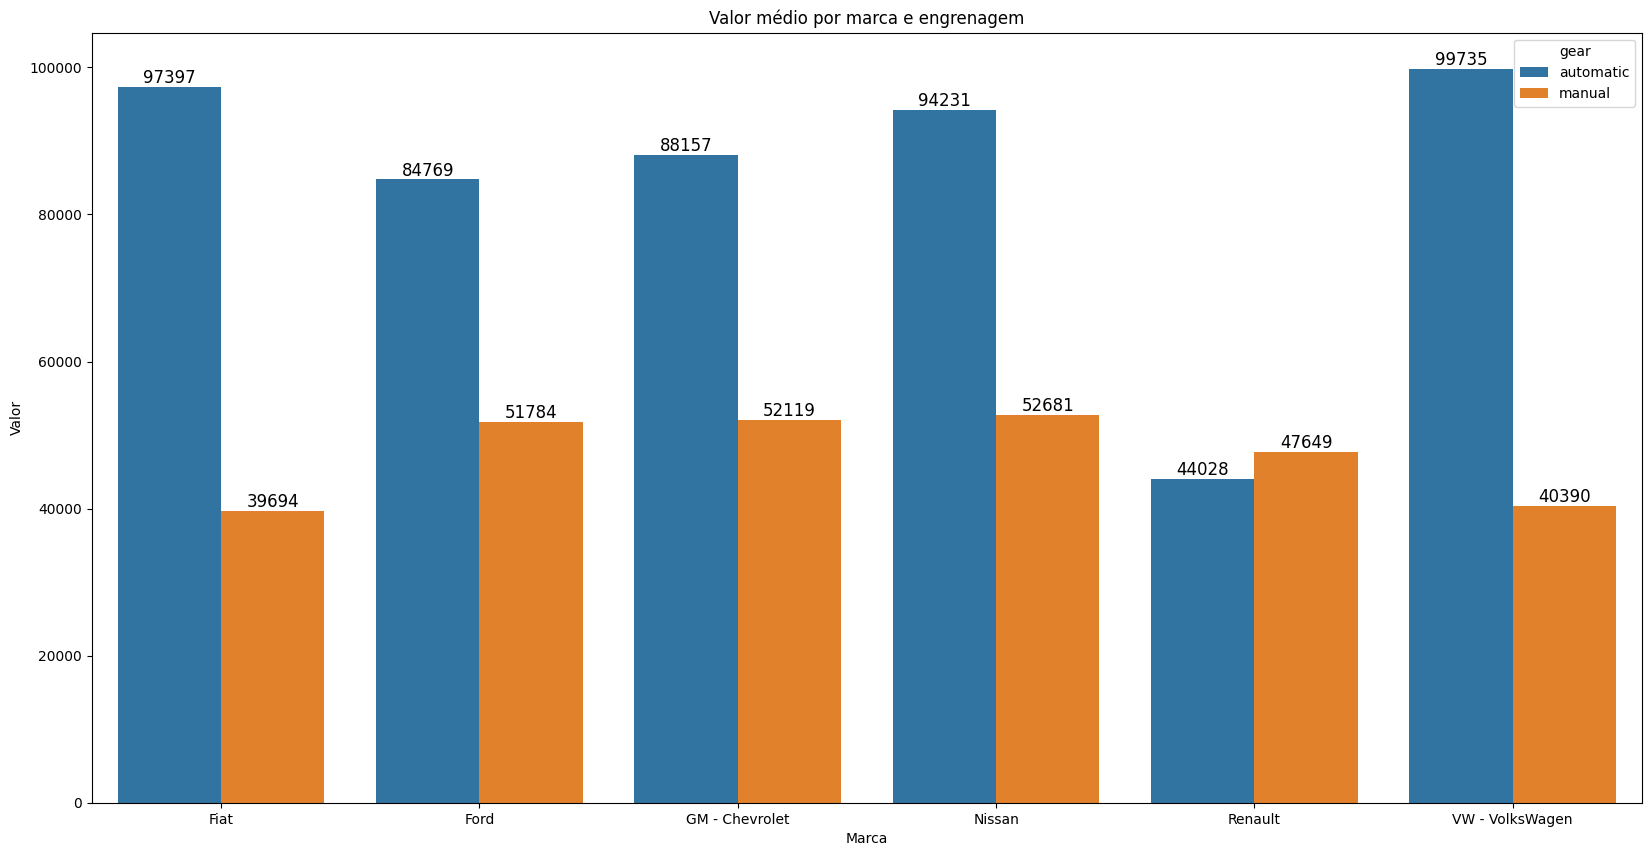

In [23]:
# Visualizando o valor médio por marca e engrenagem
plt.figure(figsize=(20,10))
plt.title('Valor médio por marca e engrenagem')
plt.ylabel('Valor')
plt.xlabel('Marca')
ax = sns.barplot(x='brand', y='valor_medio', hue='gear', data=media_valor_marca_gear, hue_order=['automatic', 'manual'])
for container in ax.containers:
    ax.bar_label(container, size=12)
plt.show()

---
5. Dê uma breve explicação (máximo de quatro linhas) sobre os resultados gerados no
item 4

Devido a menor oferta de modelos automáticos, durante o período observado, os mesmos apresentaram valores mais altos se comparado com a média de modelos de câmbio manual de mesmo fabricante, a exceção do fabricante Renault, os valores ficaram muito próximos, sendo os de câmbio automático ficaram ligeiramente abaixo.


---
6. Gere um gráfico da distribuição da média de preço dos carros por marca e tipo de
combustível

In [24]:
# Calcula a média por marca e tipo de combustível
media_valor_marca_fuel = dados.groupby(['brand', 'fuel'])['avg_price_brl'].mean().round(0) # round para arrendodar
media_valor_marca_fuel = media_valor_marca_fuel.reset_index(name='valor_medio')

In [25]:
media_valor_marca_fuel

,brand,fuel,valor_medio
0,Fiat,Alcohol,11510.0
1,Fiat,Diesel,99814.0
2,Fiat,Gasoline,37197.0
3,Ford,Alcohol,10149.0
4,Ford,Diesel,94526.0
5,Ford,Gasoline,45845.0
6,GM - Chevrolet,Alcohol,13698.0
7,GM - Chevrolet,Diesel,99817.0
8,GM - Chevrolet,Gasoline,56497.0
9,Nissan,Diesel,95534.0


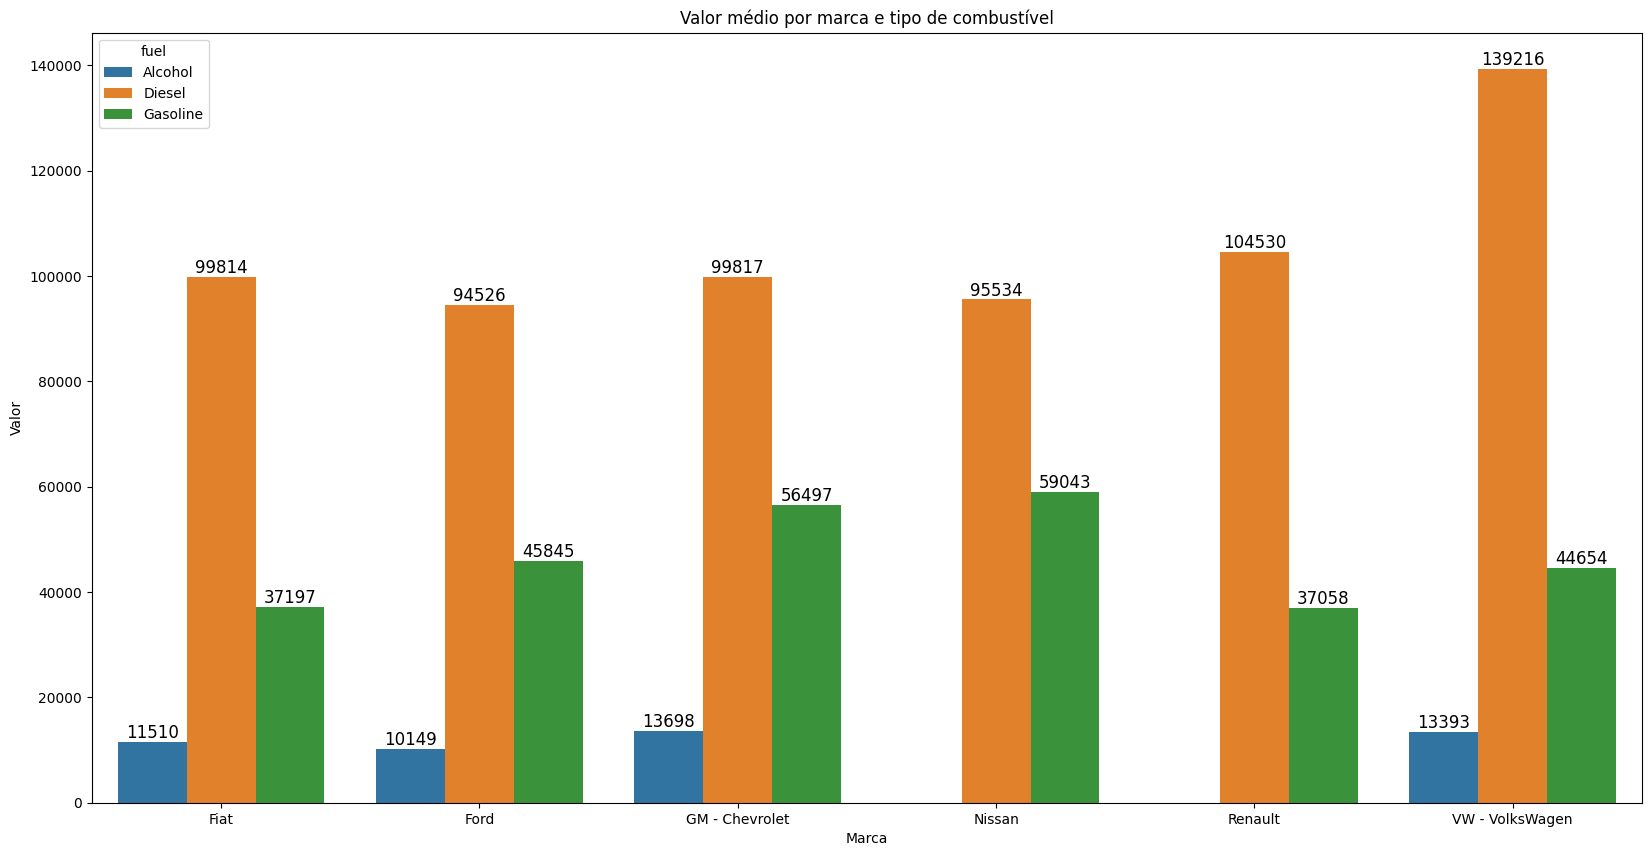

In [26]:
# Visualizando o valor médio por marca e tipo de combustível
plt.figure(figsize=(20,10))
plt.title('Valor médio por marca e tipo de combustível')
plt.ylabel('Valor')
plt.xlabel('Marca')
ax = sns.barplot(x='brand', y='valor_medio', hue='fuel', data=media_valor_marca_fuel, hue_order=['Alcohol', 'Diesel', 'Gasoline'])
for container in ax.containers:
    ax.bar_label(container, size=12)
plt.show()

---
7. Dê uma breve explicação (máximo de quatro linhas) sobre os resultados gerados no
item 6

No segmento de veículos à Diesel, existem principalmente veículos do tipo pick-up, que são veículos mais caros que outros modelos (esportivos, sedan, hatchs, etc.). Para veículos à álcool, possui menores valores devido aos incentivos governamentais para esse tipo de combustível - se comparado com os movidos à gasolina.

---
### 3 Aplicação de modelos de machine learning para prever o preço médio dos carros

---
A partir da base de dados precos_carros_brasil.csv, execute as seguintes tarefas:

1. Escolha as variáveis numéricas (modelos de Regressão) para serem as variáveis independentes do modelo. 
A variável target é avg_price. Observação: caso julgue necessário, faça a transformação de variáveis categóricas em variáveis numéricas para inputar no modelo. Indique quais variáveis foram transformadas e como foram transformadas
2. Crie partições contendo 75% dos dados para treino e 25% para teste
3. Treine modelos RandomForest (biblioteca RandomForestRegressor) e XGBoost (biblioteca XGBRegressor) para predição dos preços dos carros. Observação: caso julgue necessário, mude os parâmetros dos modelos e rode novos modelos. Indique quais parâmetros foram inputados e indique o treinamento de cada modelo
4. Grave os valores preditos em variáveis criadas
5. Realize a análise de importância das variáveis para estimar a variável target, para cada modelo treinado
6. Dê uma breve explicação (máximo de quatro linhas) sobre os resultados encontrados na análise de importância de variáveis
7. Escolha o melhor modelo com base nas métricas de avaliação MSE, MAE e R²
8. Dê uma breve explicação (máximo de quatro linhas) sobre qual modelo gerou o melhor resultado e a métrica de avaliação utilizada

---
1. Escolha as variáveis numéricas (modelos de Regressão) para serem as variáveis independentes do modelo. 
A variável target é avg_price. Observação: caso julgue necessário, faça a transformação de variáveis categóricas em variáveis numéricas para inputar no modelo. Indique quais variáveis foram transformadas e como foram transformadas

In [28]:
# Relacionar as colunas da base de dados
numericas_cols = [col for col in dados.columns if dados[col].dtype != 'str']
categoricas_cols = [col for col in dados.columns if dados[col].dtype == 'str']
print("Lista de colunas numéricas ", numericas_cols)
print("\nLista de colunas categóricas ", categoricas_cols)

Lista de colunas numéricas  ['year_of_reference', 'year_model', 'avg_price_brl']

Lista de colunas categóricas  ['month_of_reference', 'fipe_code', 'authentication', 'brand', 'model', 'fuel', 'gear', 'engine_size']


In [29]:
dados.dtypes

year_of_reference     float64
month_of_reference        str
fipe_code                 str
authentication            str
brand                     str
model                     str
fuel                      str
gear                      str
engine_size               str
year_model            float64
avg_price_brl         float64
dtype: object

In [30]:
# Converter as colunas 'brand', 'fuel' e 'gear' para números, tendo em vista a influência desses campos nos
# gráficos de média de valor. Porém optei por usar One-hot Encoding, pois os dados não representam uma ordem numérica.
# Usando pandas get_dummies

# Serão testados os seguintes cenários:
# 1 - apenas os dados numericos originais
# 2 - dados numéricos originais incluindo one-hot enconder das colunas 'brand', 'fuel' e 'gear'

one_hot_all   = pd.get_dummies(dados[['brand', 'fuel','gear']],dtype=int)

# Dataframes para os diferentes cenários
X_original = dados[numericas_cols].drop(['avg_price_brl'], axis=1)

X_all = pd.concat([X_original, one_hot_all],axis=1)

# Labels
Y = dados['avg_price_brl']

---
2. Crie partições contendo 75% dos dados para treino e 25% para teste

In [31]:
# Hyperparametros
rand_state = 42 # para reprodutibilidade dos testes
train_rate = 0.75 # 75% para o treino

In [32]:
# Cria bases de testes considerando os diferentes cenários
X_orig_train, X_orig_test, Y_orig_train, Y_orig_test = train_test_split(X_original, Y, train_size=train_rate, random_state=rand_state)
X_all_train, X_all_test, Y_all_train, Y_all_test = train_test_split(X_all, Y, train_size=train_rate, random_state=rand_state)

In [33]:
# Verificação
a = len(X_all)
b = len(X_all_train)
c = len(X_all_test)
print(f"Tamanho total da base é {a} amostras")
print(f"Numero de amostras para treino {b} ({b/a:.2%})" )
print(f"Numero de amostras para teste {c} ({c/a:.2%})" )

Tamanho total da base é 202295 amostras
Numero de amostras para treino 151721 (75.00%)
Numero de amostras para teste 50574 (25.00%)


---
3. Treine modelos RandomForest (biblioteca RandomForestRegressor) e XGBoost (biblioteca XGBRegressor) para predição dos preços dos carros. Observação: caso julgue necessário, mude os parâmetros dos modelos e rode novos modelos. Indique quais parâmetros foram inputados e indique o treinamento de cada modelo

In [34]:
# cria preditores XGBoost, RandomForest com valores default e outro com valores otimizados
predict_xg = XGBRegressor()

predict_rf = RandomForestRegressor()

# Os parametros foram escolhidos a partir do uso da biblioteca RandomizedSearchCV da Scikit-learn
predict_rf_2 = RandomForestRegressor(bootstrap=True, 
                                     max_depth=30, 
                                     max_features=0.85, 
                                     min_samples_leaf=11, 
                                     min_samples_split=9,
                                     n_estimators=180)



---
4. Grave os valores preditos em variáveis criadas

In [35]:
# treina o modelo e calcula a predição
XYs = [
    (X_orig_train,Y_orig_train, X_orig_test),
    (X_all_train, Y_all_train, X_all_test)]

# Cria list para guardar as predições
y_hat_xg_rf = []


# treina e calcula a predição em cada preditor para diferentes bases
for Xi, Yi, Xj in XYs:
    predict_xg.fit(Xi, Yi)
    predict_rf.fit(Xi, Yi)
    predict_rf_2.fit(Xi, Yi)
        
    y_hat_xg_rf.append(predict_xg.predict(Xj))
    y_hat_xg_rf.append(predict_rf.predict(Xj))
    y_hat_xg_rf.append(predict_rf_2.predict(Xj))


---
5. Realize a análise de importância das variáveis para estimar a variável target, para cada modelo treinado

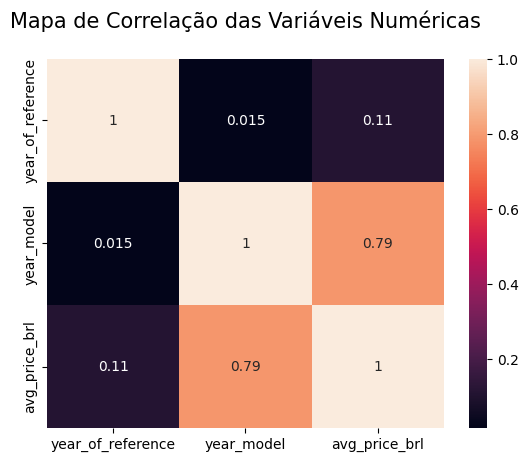

In [36]:
# Mapa de correlação das variáveis numéricas com variável Target
sns.heatmap(dados[numericas_cols].corr("spearman"), annot = True)
plt.title("Mapa de Correlação das Variáveis Numéricas\n", fontsize = 15)
plt.show()

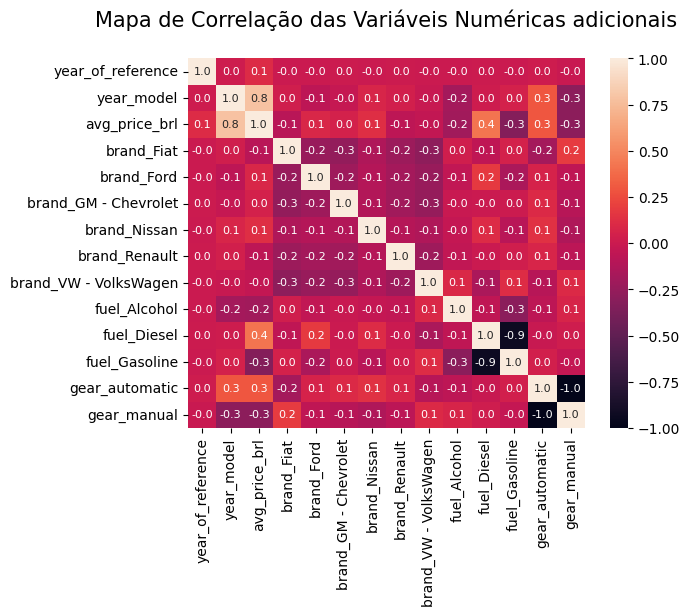

In [37]:
# Mapa de correlação das variáveis numéricas com variável Target
dados_temp = pd.concat([dados[numericas_cols], one_hot_all, ],axis=1)
sns.heatmap(dados_temp.corr("spearman"), annot = True, fmt=".1f", annot_kws={"size": 8})
plt.title("Mapa de Correlação das Variáveis Numéricas adicionais\n", fontsize = 15)
plt.show()

---
6. Dê uma breve explicação (máximo de quatro linhas) sobre os resultados encontrados na análise de importância de variáveis

Através do mapa de calor de correção entre as variáveis da base com os dados numéricos originais, a coluna 'year_of_reference' tem uma influência muito baixo enquanto a coluna 'year_model' tem uma contribuição muito grande. Já na base que leva em consideração marca, combustível e câmbio, observa-se uma influência maior desses 2 últimos.

---
7. Escolha o melhor modelo com base nas métricas de avaliação MSE, MAE e R²

In [ ]:
# obter o MSE, MAE e R² para cada modelo
def metricas(y_true, y_hat):
    """Recebe os valores reais e valores preditos e retorna um dicionário com
    o MSE, MAE e R²"""
    mse_calc = round(mean_squared_error(y_true, y_hat),2)
    mae_calc = round(mean_absolute_error(y_true, y_hat),2)
    r2_calc = round(r2_score(y_true, y_hat) * 100,2)
    metrica = {"mse": mse_calc, "mae": mae_calc, "r2": r2_calc}
    return metrica

In [ ]:
metrica_index = ['XGBoost_orig','Rainforest_orig', 'Rainforest_2_orig',
                 'XGBoost_all' , 'Rainforest_all', 'Rainforest_2_all']

y_tests = [Y_orig_test, Y_all_test]

# cria um dataframe para guardar as medidas
df_met = pd.DataFrame(columns=['mse','mae','r2'],index=metrica_index)

# insere no dataframe as metricas calculadas de cada modelo
for i in range(len(metrica_index)):
    df_met.loc[metrica_index[i]] = metricas(y_tests[int(i/3)],y_hat_xg_rf[i])
  
df_met

,mse,mae,r2
XGBoost_orig,1709265259.58,22798.42,36.49
Rainforest_orig,1709231504.94,22797.1,36.49
Rainforest_2_orig,1709304110.94,22800.02,36.49
XGBoost_all,1061966364.75,13080.84,60.54
Rainforest_all,1064667426.6,13095.99,60.44
Rainforest_2_all,1061174424.52,13089.03,60.57


O melhor modelo com base nas métricas acima foi o *RandomForestRegressor* com parâmetros diferentes do default.

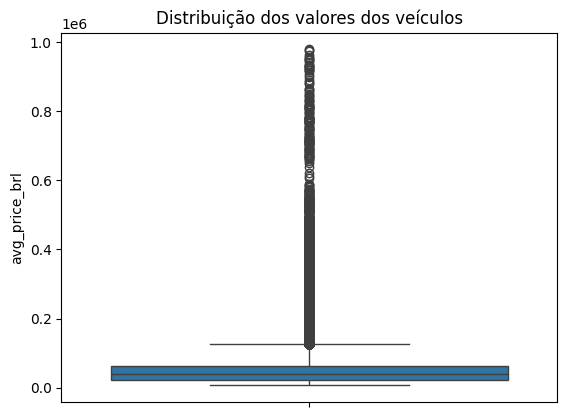

In [40]:
# Verifica se existem Outliers na coluna de preços
sns.boxplot(Y).set_title("Distribuição dos valores dos veículos");

---
8. Dê uma breve explicação (máximo de quatro linhas) sobre qual modelo gerou o melhor resultado e a métrica de avaliação utilizada

O uso da base de dados considerando as colunas de marca (brand), combustível (fuel) e tipo de câmbio (gear), provou ter mais influência no resultado final, do que apenas as colunas numéricas originais. Não foi percebido ganho muito significante entre os 3 tipos de preditores, acreditamos que seja a grande presença de Outliers que acabam trazendo distorção para esse modelo de predição.